# Real-time CFD (Constant Fraction Discriminator)
_Jacek Jagosz, Franciszek Urbański_

Celem naszego projektu było przygotować prototyp algorytmu który mógłby w przyszłości zastąpić analogowe wykrywanie zdarzeń systemem cyfrowym opartym o FPGA. Taki system mógłby uniknąć okresów martwych, oraz w teorii lepiej być w stanie wykrywać pileupy, jak widoczne na rysunku poniżej:

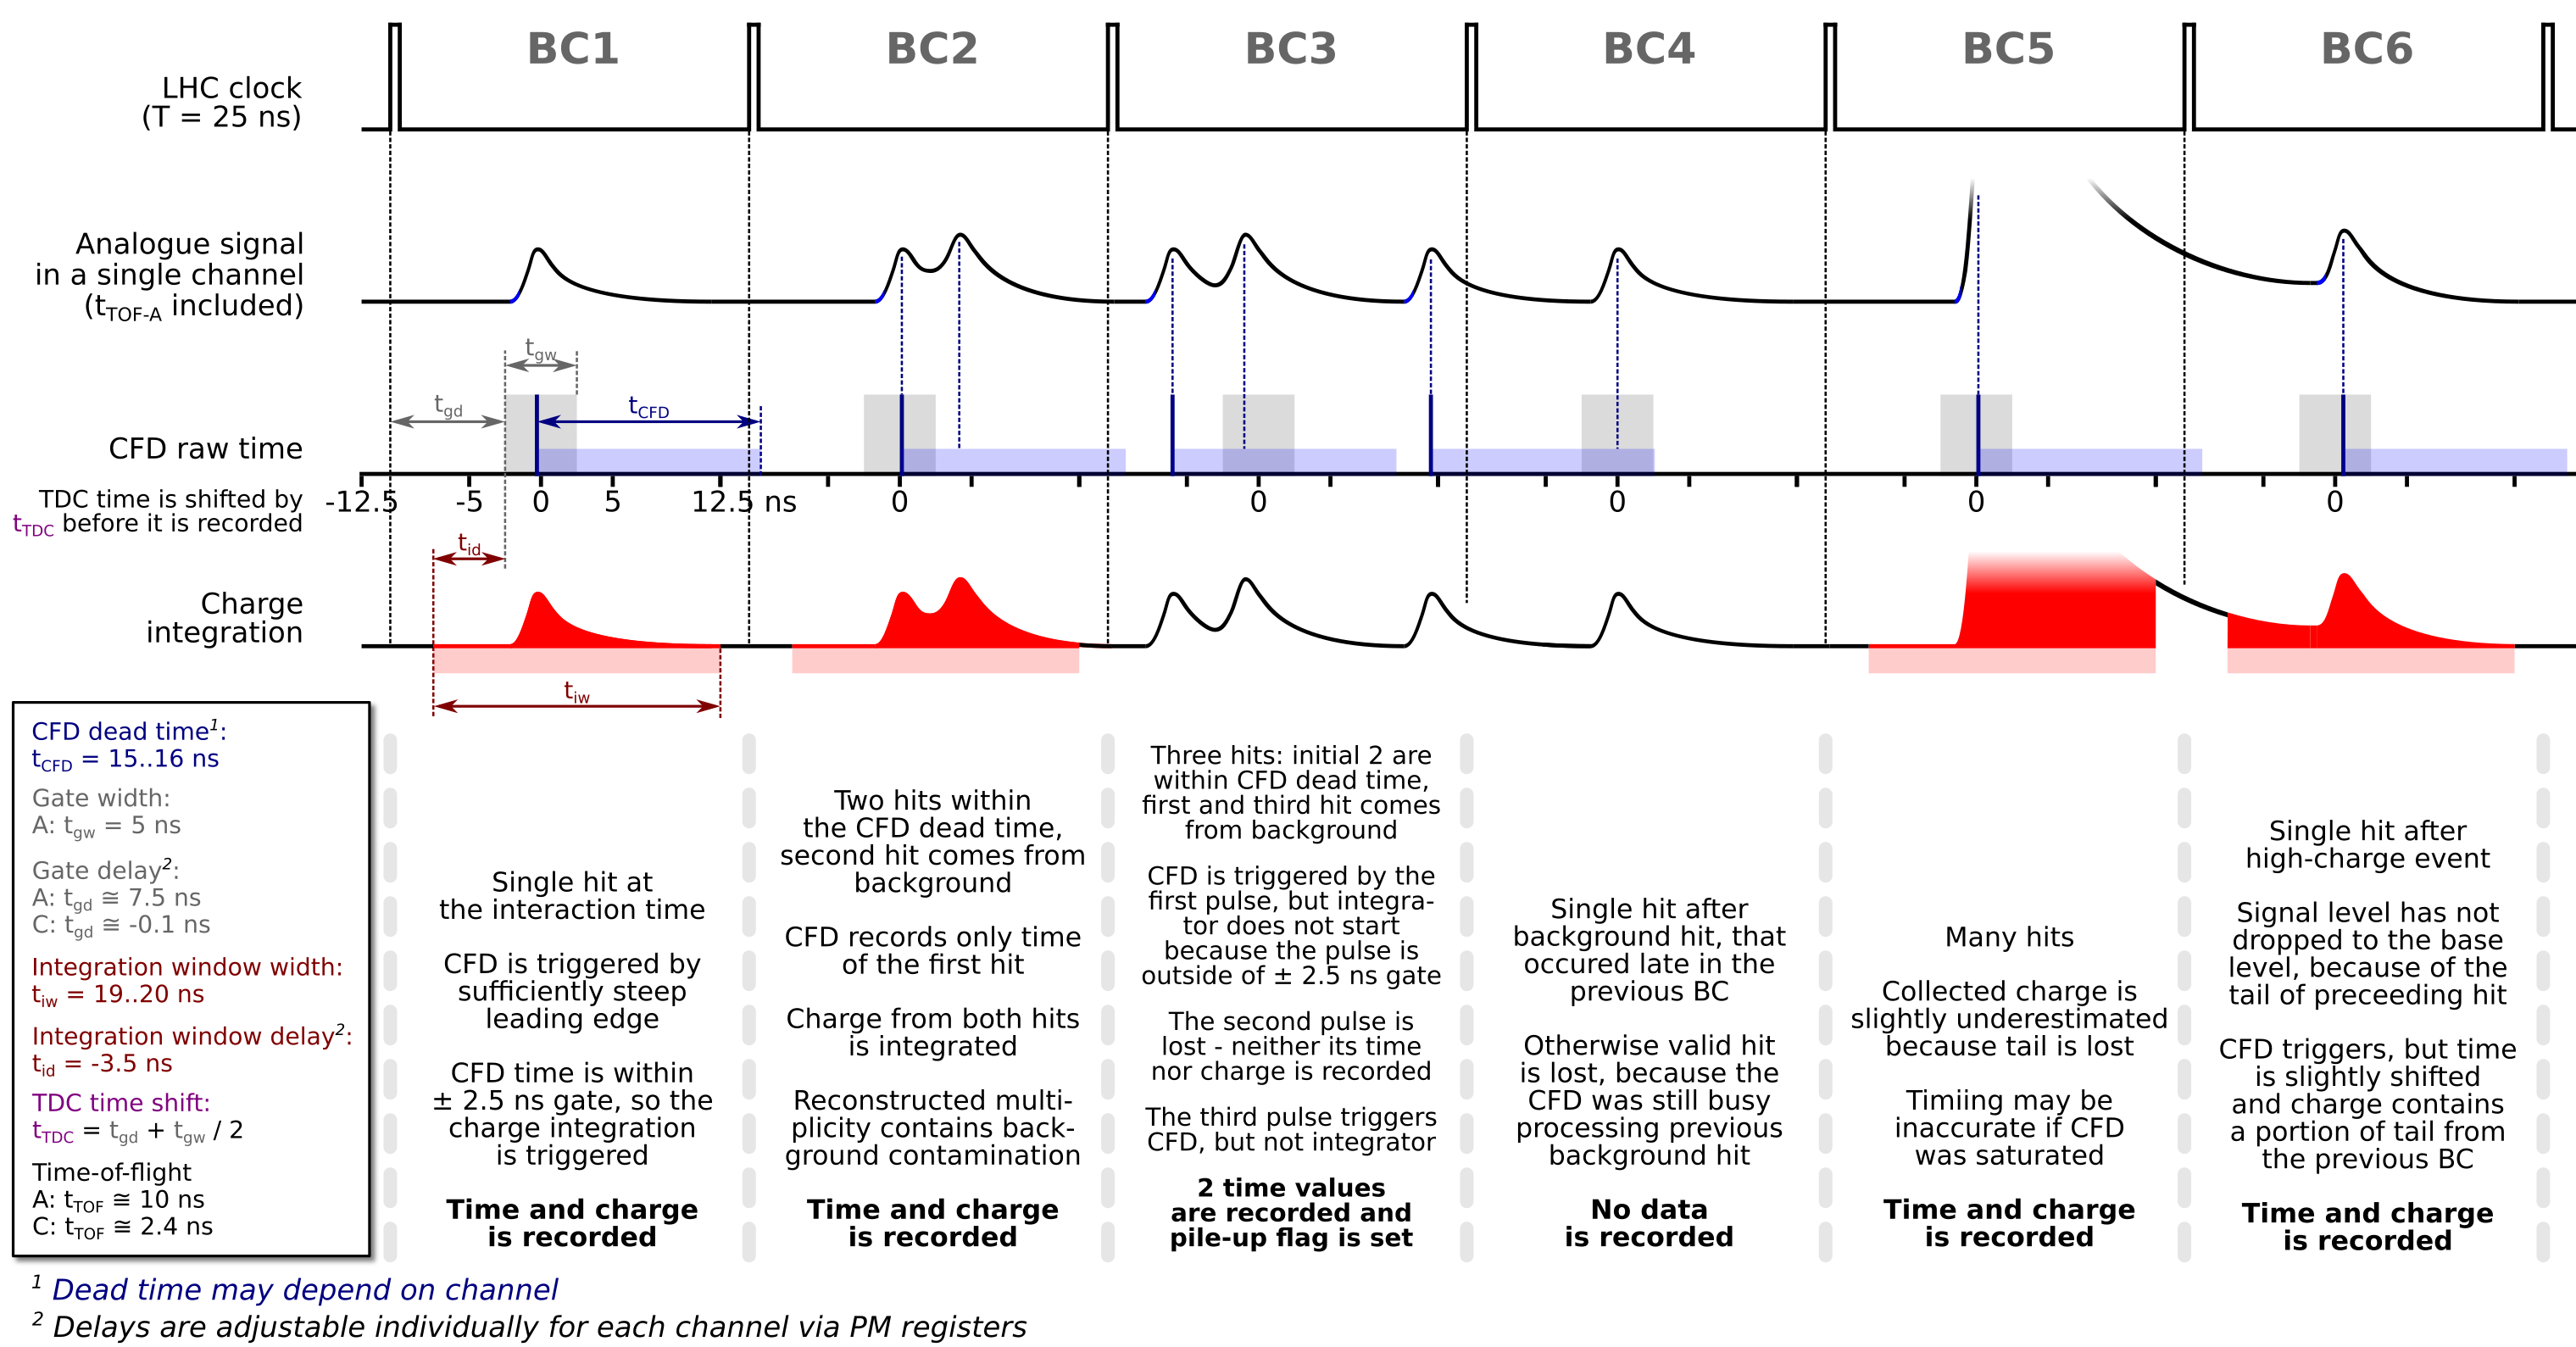

Algorytm służący do detekcji to CFD, czyli constant fraction discriminator. Pozwala on wykrywać sygnały o znacząco różnych amplitudach, gdzie wyzwolenie poziomem miało by wiele wad, jak trafienie w różną fazę sygnału, podatność na szumy czy potencjalne pominięcie mniejszych sygnałów. Można go użyć dzięki wykorzystaniu specyfiki sygnałów zwracanych przez detektor - podobne czasy naratania i opadania. Pozwala to wyzwalać się z użyciem stałego ułamka maksymalnej amplitudy sygnału, który będzie w stałym wyprzedzeniu czsowym względem szczytu.

Źródło: https://en.wikipedia.org/wiki/Constant_fraction_discriminator

Zasada działania:
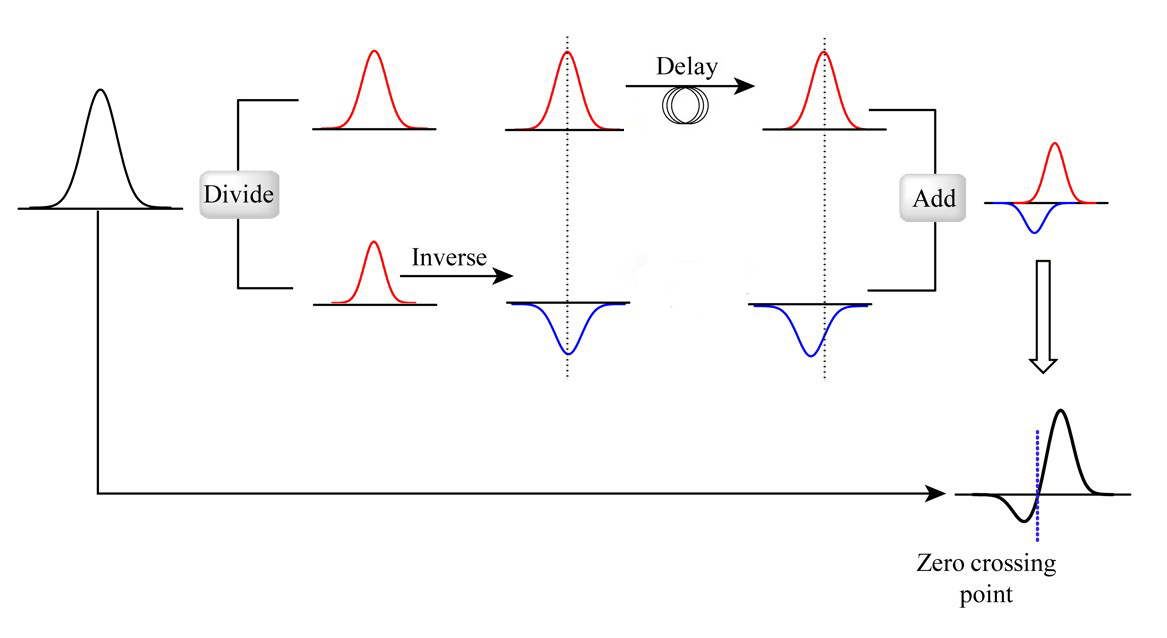

Podstawowa zasada działania CFD to że sygnał zostaje rozdzielony na 2: jeden zostaje opóźniony i wzmocniony, natomiast drugi zostaje obrócony. Moment przejścia przez 0 sumy to moment detekcji dla frakcji, jaka została ustawiona przez współczynnik przez który mnożymy opóźniony sygnał oraz samo opóźnienie.

Lecz tak proste rozwiązanie będzie bardzo podatne na szumy, dlatego można dodać histerezę do detektora przecięcia zera, oraz wejście poziomu sygnału tła, które mogło by być sterowane przez filtr dolnoprzepustowy.

## Generowanie próbek z fotopowielacza
Generowanie próbek zrobiliśmy używając pracy naukowej PMT Signal Processing - Bouke Jung poleconej przez prowadzącego.

Kształt impulsu analogowego to Gaussowska krzywa z ogonem wykładniczym. Spotykają się one o czasie t̃ = σ²/τ (zapewnia to ciągłą pochodną) i potrzebna jest stała normalizacyjna C = exp(-0.5*(σ/τ)²)

Następnie do sygnału dodaliśmy szum biały o zadanym SNR. Na koniec kwantyzujemy wartości próbek na wartości które może zmierzyć ADC o określonej szerokości bitowej.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class PMT:
  def __init__(self, dt, t_max, V_0 = 0):
    self.t = np.arange(0, t_max, dt)
    self.V = np.zeros_like(self.t, dtype=float) + V_0

  def pulse(self, t_0, q=1, sigma=3.0, tau=5.0, R_tilde=1.0):
    t_tilde = (sigma ** 2) / tau
    C = np.exp(-0.5 * (sigma / tau) ** 2)

    t_shifted = self.t - t_0

    gauss_mask = t_shifted <= t_tilde
    self.V[gauss_mask] += q * R_tilde * np.exp(-0.5 * (t_shifted[gauss_mask] / sigma) ** 2)

    exp_mask = t_shifted > t_tilde
    self.V[exp_mask] += (q * R_tilde / C) * np.exp(-t_shifted[exp_mask] / tau)

    return self

  def noise(self, snr_db):
    # Noise from SNR, assuming 1Vpp sine wave
    p_signal = (0.5 ** 2) / 2
    snr_linear = 10 ** (snr_db / 10.0)
    p_noise = p_signal / snr_linear
    noise_std = np.sqrt(p_noise)
    rng = np.random.default_rng()
    white_noise = rng.normal(loc=0.0, scale=noise_std, size=self.V.shape)
    self.V += white_noise
    return self

  def digitize(self, num_bits=12):
        max_int = (1 << num_bits) - 1
        v_clipped = np.clip(self.V, 0, 1)
        v_scaled = np.round(v_clipped * max_int)
        if num_bits <= 8:
            dtype = np.uint8
        elif num_bits <= 16:
            dtype = np.uint16
        elif num_bits <= 32:
            dtype = np.uint32
        self.V = v_scaled.astype(dtype)
        return self

  def get(self):
    return self.t, self.V


Moduł `CFD` zaimplementowany jest w stylu symulacji hardware - każdy kolejny "cykl zegara" (metoda `clk`) pobiera zestaw próbek z wejścia, a następnie wykonuje operacje arytmetyczne (opóźnienie, skalowanie, odwrócenie, dodawanie). `ZeroCrossingDetector` wykrywa przejście przez zero z histerezą, dla odporności przeciwko szumom:

- próbka uznawana za dodatnią, kiedy `x > CFD_ZERO + CFD_THRESHOLD`;
- próbka uznawana za ujemną, kiedy `x < CFD_ZERO - CFD_THRESHOLD`;
- dla próbek poza tym zakresem, kopiowany jest stan poprzedniej próbki - dzięki temu faktyczne przejście przez zero wykrywane jest po przejściu przez "region" histerezy.

In [ ]:
from collections import deque

class CFD:
  def __init__(self, data_mux, delay_samples, scale):
    self.data_mux = data_mux
    self.delay = delay_samples
    self.scale = scale

    self.prev_iter_data = np.zeros(self.delay)
    self.buff = np.zeros(self.data_mux + self.delay)


  def clk(self, input): # function executed for each clock cycle
    self.buff[:self.delay] = self.prev_iter_data
    self.buff[self.delay:] = input
    self.prev_iter_data = self.buff[self.data_mux:]
    top = self.scale * self.buff[:self.data_mux]
    bottom = self.buff[self.delay:]

    return top - bottom

In [ ]:
class ZeroCrossingDetector:
  def __init__(self, data_mux, cfd_threshold, cfd_zero):
    self.cfd_threshold = cfd_threshold
    self.cfd_zero = cfd_zero
    self.data_mux = data_mux
    self.prev_state = 0 # 0 - negative, 1 - positive

  def clk(self, input): # function executed for each clock cycle
    state = np.zeros(self.data_mux + 1)
    state[0] = self.prev_state
    for i, v in enumerate(input):
      if v > self.cfd_zero + self.cfd_threshold:
        state[i+1] = 1
      elif v < self.cfd_zero - self.cfd_threshold:
        state[i+1] = 0
      else:
        state[i+1] = state[i]
    self.prev_state = state[-1]

    out = np.zeros(self.data_mux)
    for i in range(self.data_mux):
      if state[i+1] == 1 and state[i] == 0:
        out[i] = 1
    return out

Wygenerowano impulsy o różnych amplitudach oraz nakładające się (pileup) aby przetestować działanie algorytmu w różnych przypadkach.

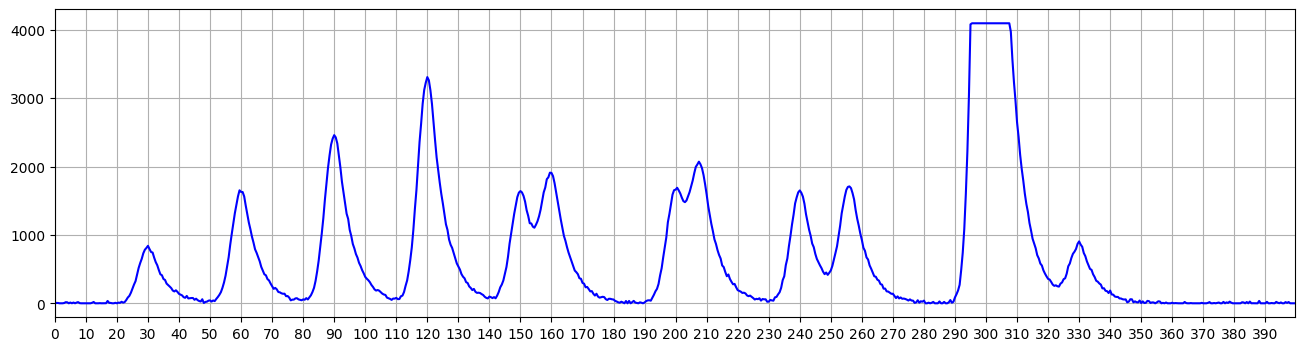

In [ ]:
# Impulse generation
DT = 0.5 # 2GHz
t, V = PMT(DT, 400) \
  .pulse(30, q=0.2) \
  .pulse(60, q=0.4) \
  .pulse(90, q=0.6) \
  .pulse(120, q=0.8) \
  .pulse(150, q=0.4) \
  .pulse(160, q=0.4) \
  .pulse(200, q=0.4) \
  .pulse(208, q=0.4) \
  .pulse(240, q=0.4) \
  .pulse(256, q=0.4) \
  .pulse(300, q=4.0) \
  .pulse(330, q=0.2) \
  .noise(40) \
  .digitize() \
  .get()

plt.figure(figsize=(16, 4))
plt.grid(True)
plt.xticks(np.arange(np.min(t), np.max(t), 10))
plt.plot(t, V, label='in', color='blue')
plt.xlim(np.min(t), np.max(t))
plt.show()

Przyjęto parametry wejścia:
- częstotliwość ADC: 2Gsps
- przychodzące w paczkach (jak z SerDes) po `DATA_MUX = 16`

Parametry CFD (opóźnienie, skala, parametry histerezy) można w komórce ustawić interaktywnie. Zauważmy, że przy tak wybranych parametrach, impulsy są trochę za szybkie aby dokładnie dobrać poziom wyzwalania. Wybraliśmy parametry, które dają wyzwalanie blisko 95% i powtarzalne wyniki dla różnych kształtów impulsu.

In [ ]:
from ipywidgets import interactive, BoundedIntText, BoundedFloatText

DATA_MUX = 16

V = V[: (len(V) // DATA_MUX) * DATA_MUX]
t = t[: (len(t) // DATA_MUX) * DATA_MUX]

def update_plot(delay, scale, cfd_threshold, cfd_zero):
    cfd = CFD(data_mux=DATA_MUX, delay_samples=delay, scale=scale)
    zcd = ZeroCrossingDetector(data_mux=DATA_MUX, cfd_threshold=cfd_threshold, cfd_zero=cfd_zero)

    sum_vals = []
    pulse_vals = []

    v_iter = iter(V)
    for v_packet in zip(*[v_iter] * DATA_MUX):
        cfd_out = cfd.clk(v_packet)
        zcd_out = zcd.clk(cfd_out)
        sum_vals.extend(cfd_out)
        pulse_vals.extend(zcd_out)

    timestamps = []
    for timestamp, pulse_detected in zip(t, pulse_vals):
        if pulse_detected == 1:
            timestamps.append(timestamp)

    plt.figure(figsize=(16, 4))

    for ts in timestamps:
        plt.axvline(x=ts, color='green')

    plt.axhspan(ymin=cfd_zero-cfd_threshold, ymax=cfd_zero+cfd_threshold,
                color='r', alpha=0.1, zorder=0, label='CFD threshold range')
    plt.xticks(np.arange(0, np.max(t), 25))
    plt.xlim(np.min(t), np.max(t))
    plt.ylim(-512, 4096)
    plt.grid(True)

    plt.plot(t, V, label='in', color='blue')
    plt.plot(t, sum_vals, label='sum', color='purple', linestyle='--')
    plt.legend(loc='upper right')
    plt.show()

    return timestamps

DELAY=3
SCALE=1 + 0.125 * 3
CFD_THRESHOLD=50
CFD_ZERO=0

interactive_plot = interactive(
    update_plot,
    delay=BoundedIntText(min=1, max=20, step=1, value=DELAY, description='DELAY'),
    scale=BoundedFloatText(min=0.5, max=5.0, step=0.125, value=SCALE, description='SCALE'),
    cfd_threshold=BoundedIntText(min=0, max=512, step=1, value=CFD_THRESHOLD, description='CFD_THRESHOLD'),
    cfd_zero=BoundedIntText(min=-256, max=256, step=1, value=CFD_ZERO, description='CFD_ZERO')
)
display(interactive_plot)

interactive(children=(BoundedIntText(value=3, description='DELAY', max=20, min=1), BoundedFloatText(value=1.37…

In [ ]:
# Verify the fraction at which the CFD was triggered
for ts in interactive_plot.result:
  idx = int(ts / DT)
  detected_level = V[idx]
  peak_level = np.max(V[idx:idx+8]) # Look for peak 8 samples after detection
  fraction = detected_level / peak_level
  print(f"{fraction:.3f}")


0.963
1.000
0.944
0.943
0.986
0.979
0.983
0.970
1.000
0.878


 ## Implementacja w SystemVerilog

została zaimplementowana tak, aby wspierała podłączenie do szybkiego przetwornika ADC przez SerDes - w jednym cylku zegara FPGA otrzymuje tablicę próbek o rozmiarze `DATA_MUX`. Do projektu założyliśmy wyjście z symulowanego ADC na poziomie 2Gsps, oraz `DATA_MUX=16`, co daje wymagany zegar FPGA o częstotliwości 125MHz (można to dostosować do zasobów sprzętowych). Logika została spakowana w IPcore, komunikujący się przez AXI-Stream. Cały moduł jest również wysoce sparametryzowany, aby zapewnić elastyczność i generyczność (parametry dot. struktury danych oraz środowiska FPGA:  `BIT_WIDTH_IN`, `DATA_MUX`, `FPGA_TIME_WIDTH`; oraz działania samego algorytmu CFD: `DELAY`, `SCALE_DIV`, `SCALE_MULT`).

Podstawową zasadę działania można podsumować jako:

**Input:** z każdym cyklem zegara otrzymuje `DATA_MUX` kolejnych próbek z ADC

**Output:** jeżeli wykryto zdarzenie CFD, przesyła jego timestamp (rzeczywisty, ale otrzymany z opóźnieniem trzech cykli zegara FPGA).

Poniższy diagram przedstawia strukturę wewnętrzną IPcore CFD.

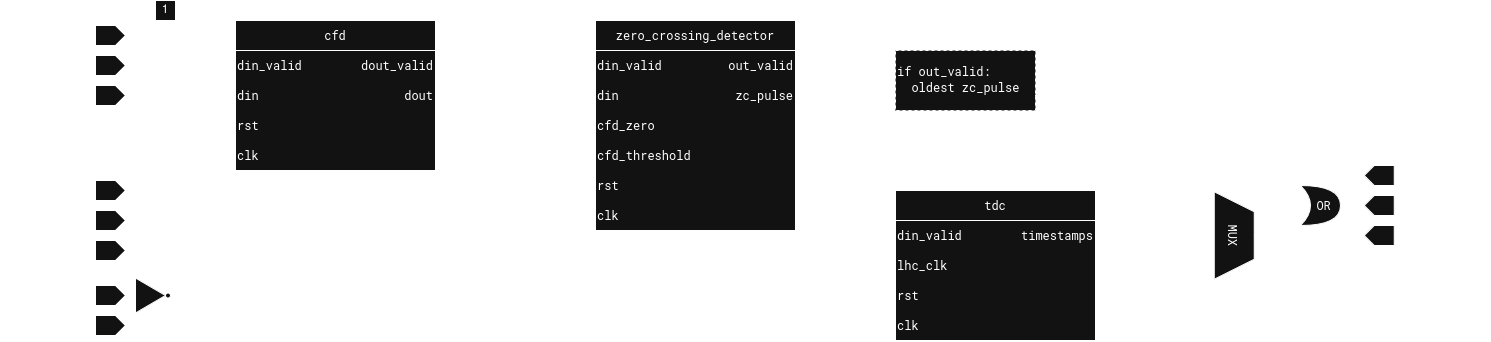

### `cfd`

Moduł CFD odpowiada za przekształcenia arytmetyczne sygnału - na jego wyjściu otrzymujemy sumę przeskalowanych (`SCALE_DIV`, `SCALE_MULT` - oba sygnały mnożone, co unika operacji dzielenia a daje względną skalę w postaci liczby wymiernej) sygnału opóźnionego (o parametr `DELAY`) oraz sygnału odwróconego. Dane wyjściowe opóźnione są w stosunku do wejścia o dwa cykle zegara FPGA:
1. buforowanie sygnału opóźnionego (ciągły bufor próbek z obecnej i poprzedniej iteracji)
2. obliczenia na sygnale opóźnionym i obecnym (skalowanie, odejmowanie)

### `zero_crossing_detector`

Moduł ZCD wykrywa momenty, w których sygnał z wyjścia CFD rosnąc przechodzi przez zero, co służy jako wyzwalacz do zgłoszenia faktycznego zdarzenia CFD. Na wejściu przyjmuje dane z wyjścia CFD, na wyjściu ma zaś tablicę flag o szerokości `DATA_MUX`, gdzie 1 na pozycji `i` oznacza, że wykryto przejście przez zero na próbce o indeksie `i`. Dzięki temu, mimo przychodzeniu danych do FPGA w paczkach, zachowujemy rozdzielczość wykrywania zdarzeń na poziomie częstotliwości próbkowania ADC.

Dla większej odporności na szumy, w module ZCD zaimplementowano również histerezę, której parametry nastawiane są przez wejścia `cfd_threshold` oraz `cfd_zero`.

Wyjście z modułu ZCD opóźnione jest w stosunku do jego wejścia o jeden cykl zegara FPGA.

### `tdc`

Moduł TDC (Time-to-Digital Converter) odpowiada za generowanie timestampów dla zdarzeń CFD. Na wyjściu otrzymujemy tablicę o rozmiarze `DATA_MUX`, zawierającą timestampy dla kolejnych próbek z wyjścia układu. Licznik czasu uruchamiany jest przez sygnał `out_valid` z ZCD. Dzięki temu, czas liczony jest dopiero gdy dane z pierwszych próbek dotrą na wyjście, co niweluje konieczność kompensacji wartości timestampów o opóźnienie układu.

Dostępne jest również wejście `lhc_clk`, które umożliwia resetowanie wewnętrznego licznika czasu (przy wykryciu zbocza narastającego). Jest to przygotowanie pod przyszłą integrację w systemie detektora, w naszej demonstracji ten sygnał jest nieużywany. Wykorzystanie go wymaga również uwzględnienia opóźnienia generacji timestampów w CFD, w stosunku do danych na wejściu, oraz potencjalnej synchronizacji fazy zegara FPGA z zegarem LHC.

### `cfd_top`
W module `cfd_top` wykonane są podłączenia wszystkich składowych modułów, oraz logika wyjścia:
- `pulse` - ustawiane na 1, jeżeli ZCD wykrył przejście przez 0 dla którejkolwiek próbki z `DATA_MUX` próbek na wyjściu
- `timestamp` - ustawiane na wartość timestamp dla próbki, dla której zostało wykryte przejście przez 0. Jeżeli przejść tych wykryto więcej niż jedno, wysyłany jest timestamp najstarczego zdarzenia. Jest to pewien odpowiednik "CFD dead time" z układu analogowego - pesymistycznie, jeżeli CFD wykryje zdarzenie na samym początku bloku danych, odrzuci wszystkie następne zdarzenia w tej ramce (u nas: 8ns).

Timestamp jest wystawiany na wyjście układu 3 cykle zegara FPGA po wystąpieniu zdarzenia, ale jest on rzeczywistym timestampem wystąpienia zdarzenia.

### `cfd_axis_wrapper`

Moduł ten jest cienkim wrapperem na logikę CFD, tak aby Vivado automatycznie wykryło ścieżkę danych kompatybilne z AXI-Stream.

Dla kompatybilności z AXI-Stream ważny jest sygnał informujący o obecności nowych danych na wejściu (`s_axis_tvalid`). Jest on propagowany przez kolejne etapy potokowego przetwarzania danych, służąc jako sygnał clock enable dla kolejnych modułów. Zakładamy, że przy wykorzystaniu CFD w faktycznym projekcie z ADC, dane będą przesyłane w sposób ciągły (`s_axis_tvalid = 1`). W naszym testowym ustawieniu (PYNQ) możemy nie być w stanie z odpowiednią prędkością przekazywać danych na wejście CFD. Z tego powodu zdecydowaliśmy, żeby brak danych zatrzymywał również liczenie czasu w CFD, dla umożliwienia demonstracji działania na danych ciągłych mimo ograniczonych możliwości DMA.


## Symulacja
Symulacja w SystemVerilog opiera się na tych samych danych wejściowych co symulacja uruchomiona w Pythonie. Plik `input.csv` jest wczytywany po 16 linijek (na opadającym zboczu zegara, by nie konfliktować z działaniem układu), kolejne próbki wkładane są na wejście układu. Do pliku `output.csv` wypisywany jest kolumnami stan układu:

- `realtime` - czas symulacji
- `timestamp` - czas przypisany danej próbce
- `din_valid`, `din` - dane wejściowe
- `dout_valid`, `dout` - dane wyjściowe z CFD (suma)
- `zcd_out_valid`, `pulse`, `out_timestamp` - ostateczne wyjście układu

Dodatkowo, za pomocą funkcji `$urandom_range` dodawane są przerwy w danych wejściowych - odczyt z pliku jest przerywany na 1 lub 2 cykle zegara, a sygnał `din_valid` ustawiany jest na 0. Pozwoliło to upewnić się, że układ zadziała nawet w przypadku przerw w transmisji.

Skrypt Pythona `analysis/plot.py` umożliwia wyrysowanie wykresu, uwzględniając opisane opóźnienia wprowadzone przez układ oraz przerwy w danych. Wykres, umieszczony poniżej, jest w pełni zgodny z rezultatami symulacji z Pythona.

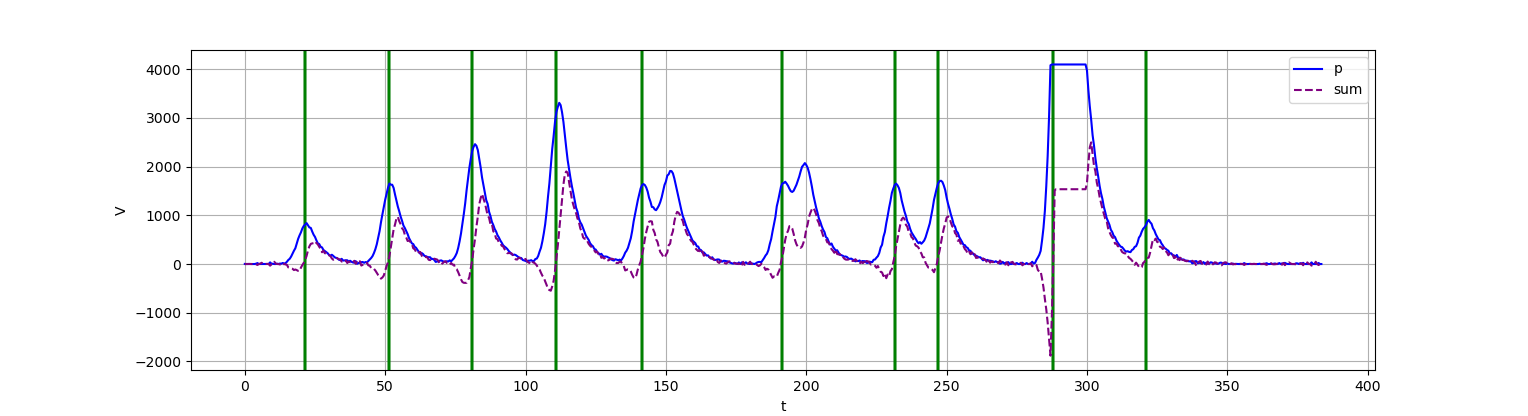

## Diagram blokowy Vivado (PYNQ overlay)
By przetestować nasz moduł z użyciem PYNQ musieliśmy połączyć szyny procesora z wejściem i wyjściem układu. Zaczęliśmy od bloku DMA by być w stanie podawać róbki, następnie konieczność była dopasowania szerokości magistrali z 256bitów na 192 oraz 24 wymagane przez nasz moduł do odpowiednio próbek i parametrów.
Wejście parametrów zostało zrealizowane używając AXI GPIO, w teorii można by to było uprościć bezpośrednio dostarczając interfejs AXII do modułu tak jak jest to z próbkami, ale chcieliśmy możliwie jak najmniej modyfikować moduł z oryginalnej symulacji
Na wyjściu układu zastosowaliśmy bufor FIFO, w zależności od potrzeb dla bloków które mają korzystać z wyjściowych danych może on zostać pominięty, jeśli wiemy że następny blok nadąży z przyjmowaniem informacji.
I bufor FIFO i sam "surowy" interfejs AXII Stream działał dopiero po wymuszeniu parametru tlast na 1.

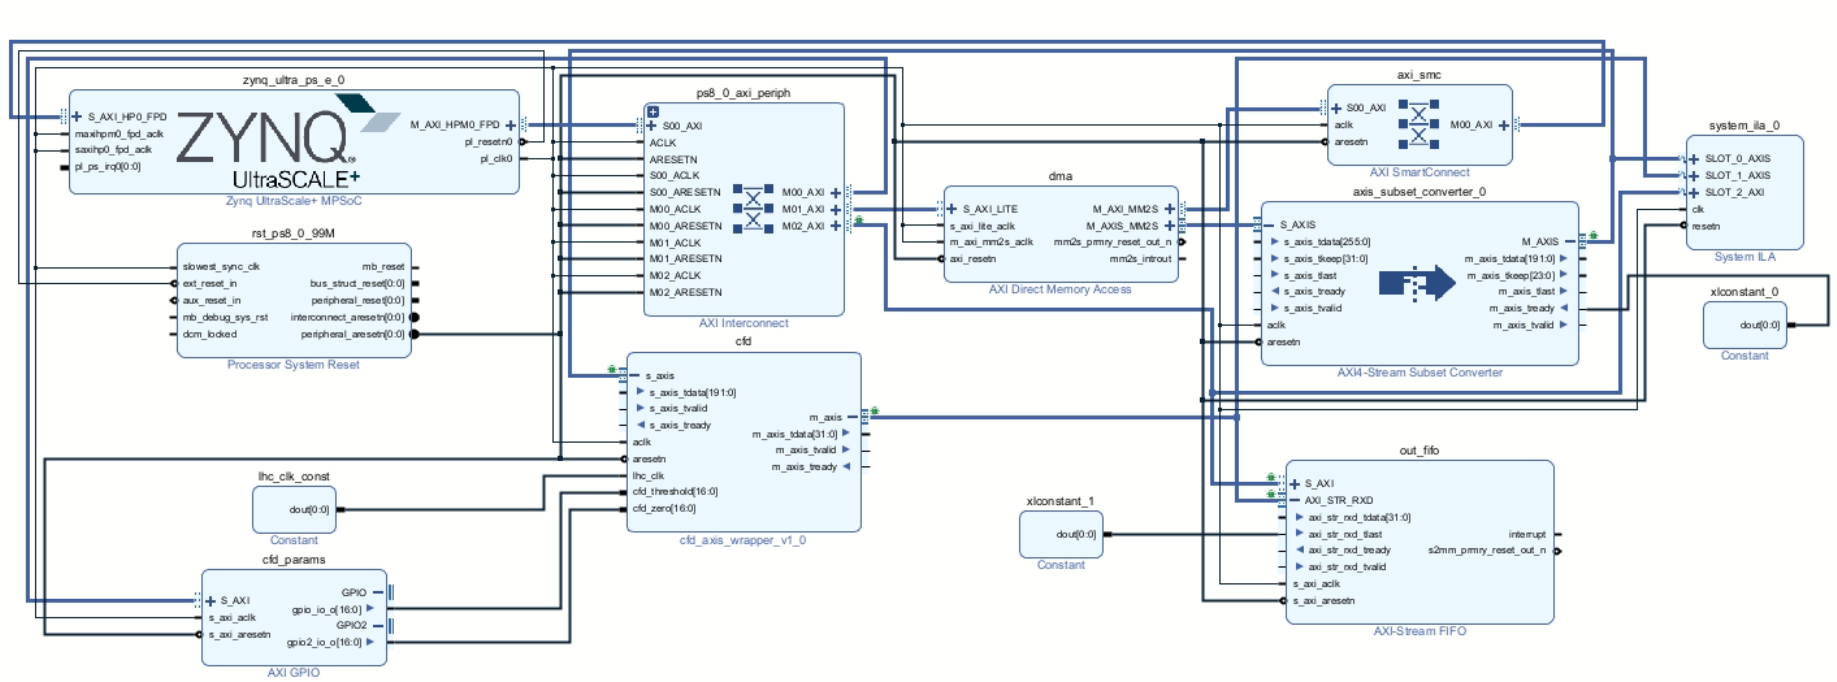

## Uruchomienie na PYNQ
Po stronie pythona musieliśmy przygotować funkcję która załaduje wszystkie próbki z wygenerowanego w symulacji input.csv używając DMA, następnie odbieraliśmy czasy detekcji

Mieliśmy trudności z uruchomieniem całej komunikacji z użyciem PYNQ. Bardzo pomocne okazało się użycie ILA i sprawdzenie danych na kolejnych fragmentach magistrali. Dodawanie ILA jest bardzo proste, za każdym razem usuwaliśmy poprzednio wygenerowany analizator, następnie prawy przyciskiem zaznaczaliśmy szyny które chcemy podglądnąć i generowaliśmy block design ponownie. Problem został rozwiązany przez ręczne ustawienie sygnału `tlast` na 1.

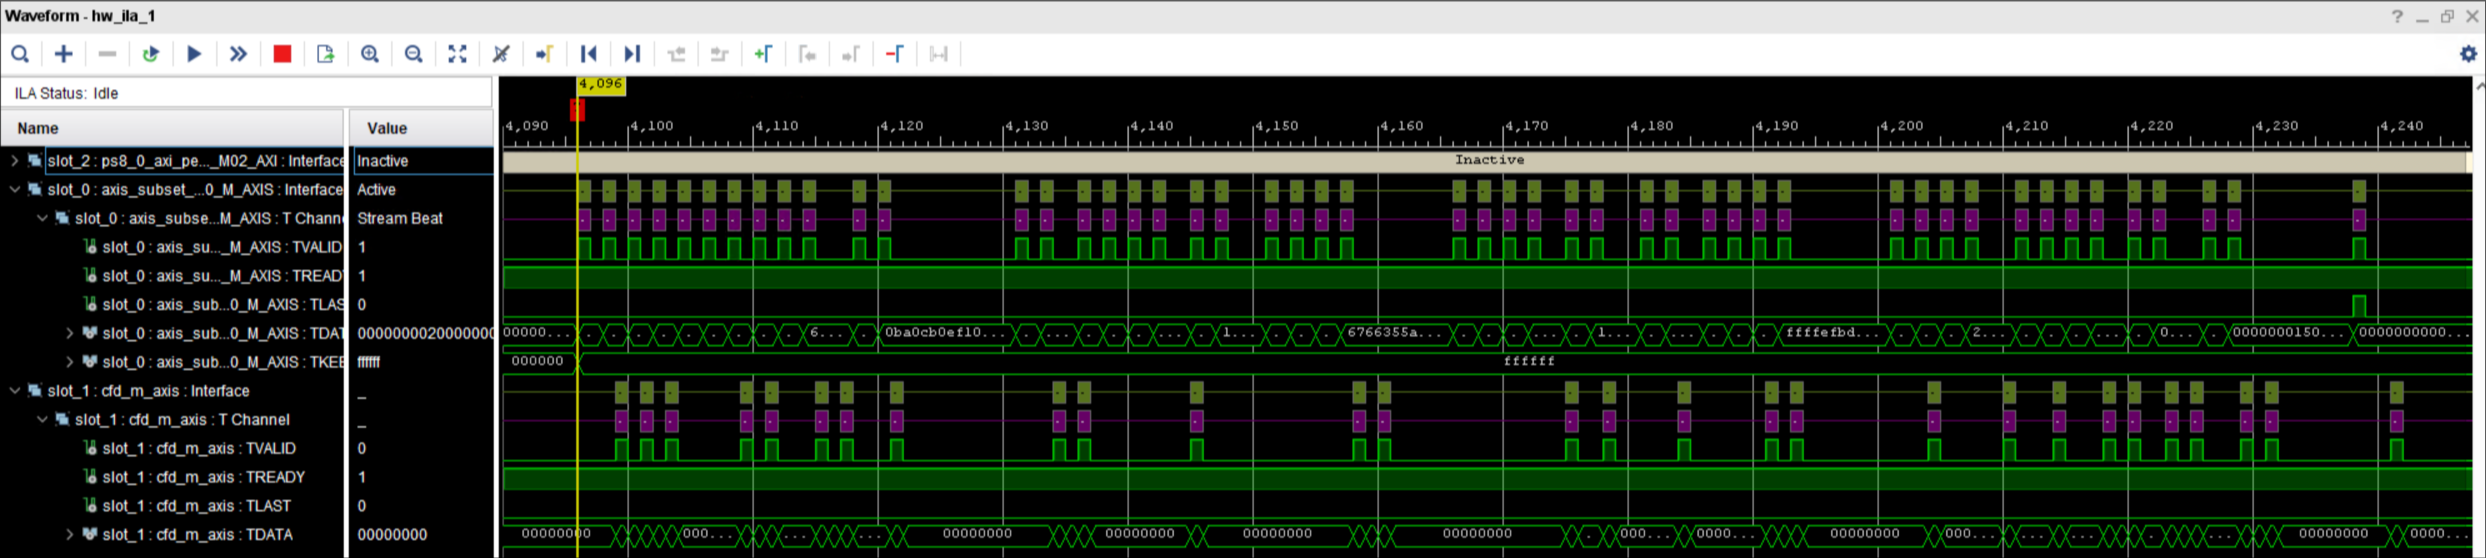

Na ILA widać że procesor nie jest w stanie wysłać ciągłego strumienia próbek, spodziewamy się że procesor nie nadąża z wysyłaniem próbek po DMA. Na szczęście obsługa din_valid działa poprawnie i wynik jest dokładnie taki sam jak w symulacji.

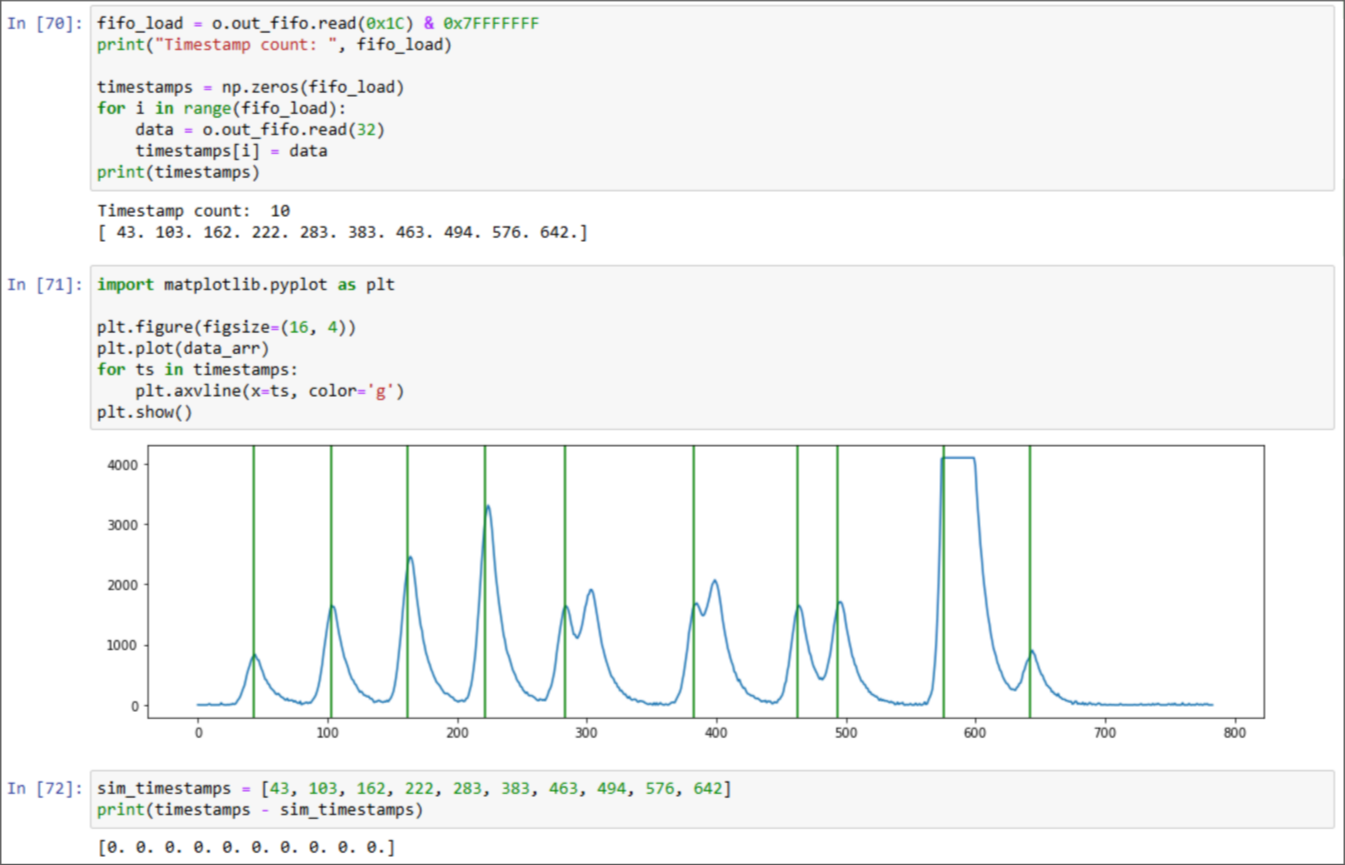

Przedstawiony zrzut ekranu jest z uruchomienia zsyntezowanego kodu na PYNQ. Zrobiono porównanie timestampów otrzymanych w symulacji z tymi, które otrzymaliśmy na PYNQ - mamy pełną zgodność wartości.

## Analiza ograniczeń częstotliwości
Syntezowany design na użytym sprzęcie osiągnął taktowanie 100MHz, czyli bardzo bliskie docelowego, mimo zawarcia bloków ILA.

Chcąc zrozumieć które ścieżki najbardziej ograniczały zegar by móc go zoptymalizować użyliśmy Report Timing Summary w Vivado i popatrzyliśmy na ścieżki które posiadają *worst negative slack*. Zgodnie z oczekiwaniami największym problemem były ścieżki związane z ILA (3.557ns), ale co nas zaskoczyło to że niewiele gorszy okazał się downsizer AXI (4.056ns).